# `kNNpy.kNN_3D.TracerFieldCross3D` Tutorial: Cross-Clustering using $k$-nearest neighbour distributions on 3D dataset

**Author**: Eishica Chand (email:[eishica.chand@students.iiserpune.ac.in](mailto:eishica.chand@students.iiserpune.ac.in))
\
**Date**: 13 July 2026\
**kNNpy version**: 0.0.1

#### This notebook presents a simple guide on how to use the `TracerFieldCross3D` module of `kNNpy.kNN_3D` to compute the 3D tracer-field cross kNN distributions for given data and interpret the results. The basic functionalities of the module are illustrated using cosmological simulation data. A detailed API [documentation](https://kitnenikatnivasi.github.io/kNNpy_documentation_html/kNNpy/kNN_2D_Ang.html) and source code for the module is available on the `kNNpy` [website](https://kitnenikatnivasi.github.io/).

## Table of Contents

1. [Imports and Setup](#imports)
    - [Plotting preferences](#plot-prefs)
    - [Functions used](#functions)
2. [Main](#main)
    - [2.1 Load Mock Data](#mock)
    - [2.2 Why Cross-Correlations?](#cross-corr-motivation)
    - [2.3 Generate Query Points](#query-points)
    - [2.4 Theoretical Poisson CDFs and Bin Selection](#poisson-bins)
    - [2.5 Density Threshold for the Continuous Field](#density-threshold)
    - [2.6 Single-Realisation Cross-Clustering: `TracerFieldCross3D`](#cdf)
    - [2.7 Multi-Realisation Cross-Clustering: `TracerFieldCross3D_DataVector`](#datavector)


<a name="imports" id="imports"></a>
## 1. Imports and Setup


In [1]:
#Importing external libraries

import numpy as np
from matplotlib import pyplot as plt, ticker as mticker
import matplotlib.colors as colors
import readfof
import readgadget
import copy
import MAS_library as MASL
import os
import sys
import warnings
from scipy.special import factorial
from matplotlib.ticker import MaxNLocator

#We prefer turning off the annoying warnings thrown by Python. Comment out the line below if you prefer to view the warnings as they arise.
warnings.filterwarnings('ignore')

#Importing the kNNpy modules that will be used in this tutorial

#Necessary for relative imports (see https://stackoverflow.com/questions/34478398/import-local-function-from-a-module-housed-in-another-directory-with-relative-im)
module_path = os.path.abspath(os.path.join('..'))           # '../../' is needed because the parent directory is two directories upstream of this test directory

if module_path not in sys.path:
    sys.path.append(module_path)

from kNNpy import HelperFunctions as hf
from kNNpy import kNN_3D
from kNNpy.kNN_3D import TracerFieldCross3D
from kNNpy.kNN_3D import TracerFieldCross3D_DataVector


<a name="plot-prefs" id="plot-prefs"></a>
### 1.1 Plotting Preferences

We define our `matplotlib` plotting preferences below; you can change them to your liking. Remember to set `usetex=False` if you do not have $\LaTeX$ installed.


In [2]:
#Matplotlib settings

plt.rcParams['font.family'] = 'serif'
plt.rc('text', usetex=True)
plt.rcParams.update({'font.size': 15})
plt.rcParams["axes.linewidth"] = 2*0.8
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["xtick.major.width"] = 2*0.8
plt.rcParams["ytick.direction"] = 'in'
plt.rcParams["ytick.major.width"] = 2*0.8
plt.rcParams["xtick.major.size"] = 2*3.5
plt.rcParams["ytick.major.size"] = 2*3.5
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.width"] = 2*0.6
plt.rcParams["ytick.minor.width"] = 2*0.6
plt.rcParams["xtick.minor.size"] = 2*2
plt.rcParams["ytick.minor.size"] = 2*2

DefaultColorCycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
# BrightColors = ['cyan', 'yellow', 'lime', 'pink', '#E0B0FF']
c      =  ["#710707", "#070C47", "#0E650E", "#1C859C", "#9A1E89",  "#D76F33", "#5C558A", "#2F1728", '#D7A633', '#5C8A55', '#2F8A17']


<a name="functions" id="functions"></a>
### 1.2 Functions Used


In [3]:
def PoissonUniformCDFs(nbar, R_array, k):
    
    cdf_vals = np.zeros_like(R_array)

    for j, R in enumerate(R_array):
        lam     = (4/3) * np.pi * R**3 * nbar  # Poisson rate (expected count in volume)
        exp_lam = np.exp(-lam)
        total   = 0.0
        for i in range(k):  # P(N < k) = sum_{i=0}^{k-1} Poiss(i; λ)
            total += (lam**i / factorial(i, exact=False)) * exp_lam
        cdf_vals[j] = total

    return 1 - cdf_vals


<a name="main" id="main"></a>
## 2. Main


<a name="mock" id="mock"></a>
### 2.1 Load Mock Data

In this tutorial, we illustrate how to use `kNNpy` to quantify 3D tracer-field cross-correlations with the $k$-nearest neighbour distributions. For this purpose, we use the publicly available [Quijote simulations](https://quijote-simulations.readthedocs.io/en/latest/).


#### Load Particle Snapshot at Redshift $z=0$


In [4]:
DataPath='../kNNpy/Data'

In [5]:
snapshot = f"{DataPath}/Quijote_simulations/fiducial_LR/0/snapdir_004/snap_004"
ptype    = [1] #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)

# read header
header   = readgadget.header(snapshot)
Boxsize  = header.boxsize/1e3  #Mpc/h
Nall     = header.nall         #Total number of particles
redshift = header.redshift     #redshift of the snapshot

# read positions of the particles
pos_part = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h
pos_part = pos_part.astype(np.float32)
print(f"Snapshot read: {snapshot}")
print(f"Important Information:\nBoxSize = {Boxsize:.2f} Mpc/h,\nNall = {Nall[1]},\nredshift = {redshift:.2f}")

Snapshot read: ../kNNpy/Data/Quijote_simulations/fiducial_LR/0/snapdir_004/snap_004
Important Information:
BoxSize = 1000.00 Mpc/h,
Nall = 16777216,
redshift = 0.00


#### Load Halo Catalog at Redshift $z=0$


In [6]:
snapnum, redshift = 4,0            # saving convention of Quijote
halo_dir =  f"{DataPath}/Quijote_simulations/fiducial_LR/0"

# read the halo catalogue
FoF = readfof.FoF_catalog(halo_dir, snapnum, long_ids=False,swap=False, SFR=False, read_IDs=False)

# get the properties of the halos
pos_halo      =     FoF.GroupPos/1e3            #Halo positions in Mpc/h
pos_halo      =     pos_halo.astype(np.float32)
mass_halo     =     FoF.GroupMass*1e10          #Halo masses in Msun/h

print(f"Informations about the halo catalogue at z={redshift}:")
print(f"Number of halos: {len(pos_halo)}")
print(f"Mass range: {np.min(mass_halo):.2e} - {np.max(mass_halo):.2e} Msun/h")
print(f"Position range: {np.min(pos_halo,axis=0)} - {np.max(pos_halo,axis=0)} Mpc/h")

Informations about the halo catalogue at z=0:
Number of halos: 406660
Mass range: 1.31e+13 - 5.47e+15 Msun/h
Position range: [0.00017787 0.00561007 0.00248465] - [999.996  999.9956 999.9966] Mpc/h


#### Select the 100,000 Most Massive Halos


In [7]:
# Select 100000 most massive halos for the analysis
Nhalos        = 100000
idx           = np.argsort(mass_halo)[::-1][:Nhalos]
pos_halo_use  = pos_halo[idx]
mass_halo_use = mass_halo[idx]

print(f"Number of halos: {len(pos_halo_use)}")
print(f"Mass range: {np.min(mass_halo_use):.2e} - {np.max(mass_halo_use):.2e} Msun/h")
print(f"Position range: {np.min(pos_halo_use,axis=0)} - {np.max(pos_halo_use,axis=0)} Mpc/h")


Number of halos: 100000
Mass range: 4.66e+13 - 5.47e+15 Msun/h
Position range: [0.00849513 0.01377274 0.00263293] - [999.98865 999.99554 999.9966 ] Mpc/h


#### Compute the Matter Overdensity Field


In [8]:
grid        =    512 
MAS         =   'CIC'   # mass-assigment scheme
verbose     =    True    # print information on progress

del_m   = np.zeros((grid,grid,grid), dtype=np.float32)

MASL.MA(pos_part, del_m, Boxsize, MAS, verbose=verbose)
del_m /= np.mean(del_m, dtype=np.float64);  del_m -= 1.0

print(f"Mean and Standard Deviation:\ndelta_m: {np.mean(del_m):.3f}, {np.std(del_m):.3f}")



Using CIC mass assignment scheme
Time taken = 0.469 seconds

Mean and Standard Deviation:
delta_m: 0.000, 3.857


#### Matter Field $z$-axis Projection and Halos Across the Region


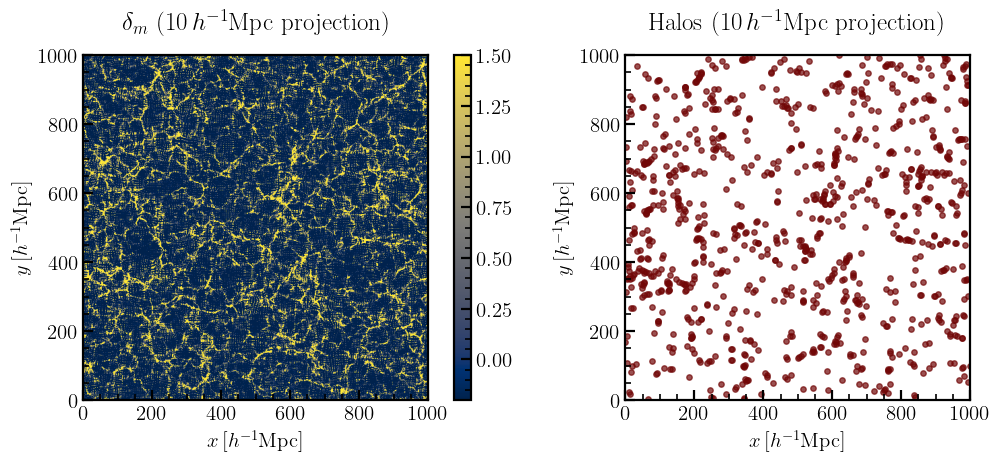

In [9]:
proj_depth = 10
dz = Boxsize / del_m.shape[2]
nz = int(proj_depth / dz)

z0 = del_m.shape[2] // 2 - nz // 2
z1 = z0 + nz

# Matter overdensity projection
proj_m = np.mean(del_m[:, :, z0:z1], axis=2)

# Halo positions in the same slab
mask = (pos_halo_use[:, 2] >= z0*dz) & (pos_halo_use[:, 2] < z1*dz)
halo_xy = pos_halo_use[mask]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

# Matter field
im = ax[0].imshow( proj_m.T, origin='lower', extent=[0, Boxsize, 0, Boxsize], cmap='cividis', vmin=-0.2, vmax=1.5)
ax[0].set_title(rf'$\delta_m$ (${proj_depth}\,h^{{-1}}\mathrm{{Mpc}}$ projection)', y=1.05)
ax[0].set_xlabel(r'$x\,[h^{-1}\mathrm{Mpc}]$')
ax[0].set_ylabel(r'$y\,[h^{-1}\mathrm{Mpc}]$')

fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.01)

# Halo scatter
ax[1].scatter(halo_xy[:, 0], halo_xy[:, 1], s=15, c=c[0], alpha=0.7)
ax[1].set_xlim(0, Boxsize)
ax[1].set_ylim(0, Boxsize)
ax[1].set_aspect('equal')
ax[1].set_title(rf'Halos (${proj_depth}\,h^{{-1}}\mathrm{{Mpc}}$ projection)', y=1.05)
ax[1].set_xlabel(r'$x\,[h^{-1}\mathrm{Mpc}]$')
ax[1].set_ylabel(r'$y\,[h^{-1}\mathrm{Mpc}]$')

# plt.tight_layout(w_pad=2)
plt.show()

**Interpretation:** The projected matter overdensity field (left panel) shows the cosmic web — filaments and clusters of enhanced density (brighter regions) separated by voids (darker regions). The halo positions in the same slab (right panel) trace this same underlying structure: halos preferentially sit in and around the high-density regions of the matter field rather than being spread out uniformly. This qualitative, by-eye correlation is exactly what we will quantify below using the tracer-field kNN-CDFs.


<a name="cross-corr-motivation" id="cross-corr-motivation"></a>
### 2.2 Why Cross-Correlations?

Cross-correlations are a useful tool in cosmological clustering analyses. They are advantageous over auto-correlations because the noise and systematics of different tracer samples are usually uncorrelated and therefore cancel out, resulting in a higher signal-to-noise ratio (SNR).


<a name="query-points" id="query-points"></a>
### 2.3 Generate Query Points

The query points are the locations from which the nearest-neighbour distances are computed. The number of query points is determined by the scales of interest, and the tracer number density should be suitable to probe those scales. The average inter-query separation should be much smaller than the scales of interest.


In [10]:
QueryPos = hf.create_query_3D('random', 256, Boxsize)
QueryPos = QueryPos.astype(np.float32)
print(f"Average Inter Query Separation~", (len(QueryPos)/(Boxsize**3))**(1/3))

Average Inter Query Separation~ 0.256


<a name="poisson-bins" id="poisson-bins"></a>
### 2.4 Theoretical Poisson CDFs and Bin Selection

Bins well measured for Poisson-data CDFs.


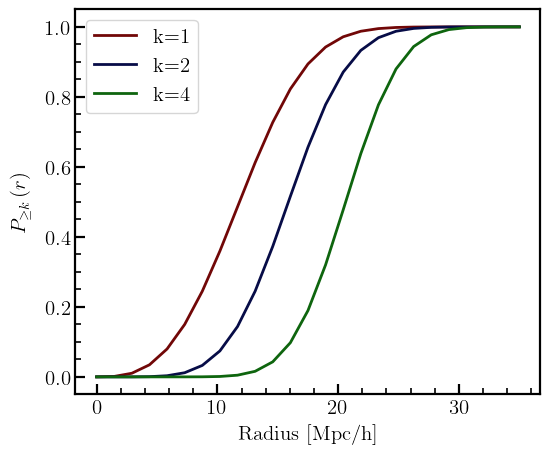

In [11]:
k_list = [1, 2, 4]
r_max = 35
num_r = 25
nbar  = Nhalos/(Boxsize**3)
Rbins = np.zeros((len(k_list), num_r))

for i, k in enumerate(k_list):
    Rbins[i] = np.linspace(0, r_max, num_r)

Theoretical_Uniform_CDFs_test = []

for i, k in enumerate(k_list):
    Theoretical_Uniform_CDFs_test.append(PoissonUniformCDFs(nbar, Rbins[i], k))

plt.figure(figsize=(6, 5))
for i, k in enumerate(k_list):
    plt.plot(Rbins[i], Theoretical_Uniform_CDFs_test[i], color = c[i], lw=2, label=f'k={k}')

plt.xlabel('Radius [Mpc/h]')
plt.ylabel(r'$P_{\geq k} \,(r)$', labelpad=10)
plt.legend()
plt.show()
plt.close()


In [12]:
low_bin  = np.zeros(len(k_list)).astype(int)
high_bin = np.zeros(len(k_list)).astype(int)

for i, k in enumerate(k_list):
    low_bin[i]  = np.searchsorted(Theoretical_Uniform_CDFs_test[i], 0.05)
    high_bin[i] = np.searchsorted(Theoretical_Uniform_CDFs_test[i], 0.95)
    print(f'{k}NN', '{:.2f}'.format(Rbins[i][low_bin[i]]), '{:.2f}'.format(Rbins[i][high_bin[i]]))

num_Rbins  = 10
Rbins_pick = np.zeros((len(k_list), num_Rbins))

for i, k in enumerate(k_list):
    Rbins_pick[i] = np.linspace(Rbins[i][low_bin[i]]*0.95, Rbins[i][high_bin[i]]*1.05, num_Rbins)

for i, k in enumerate(k_list):
    print(f'\nRadial bins for {k}NN-CDF:\n', Rbins_pick[i])
    print(f'\nNumber of bins for {k}NN-CDF: ', len(Rbins_pick[i]))


1NN 5.83 20.42
2NN 10.21 23.33
4NN 16.04 27.71

Radial bins for 1NN-CDF:
 [ 5.54166667  7.30787037  9.07407407 10.84027778 12.60648148 14.37268519
 16.13888889 17.90509259 19.6712963  21.4375    ]

Number of bins for 1NN-CDF:  10

Radial bins for 2NN-CDF:
 [ 9.69791667 11.34259259 12.98726852 14.63194444 16.27662037 17.9212963
 19.56597222 21.21064815 22.85532407 24.5       ]

Number of bins for 2NN-CDF:  10

Radial bins for 4NN-CDF:
 [15.23958333 16.77893519 18.31828704 19.85763889 21.39699074 22.93634259
 24.47569444 26.0150463  27.55439815 29.09375   ]

Number of bins for 4NN-CDF:  10


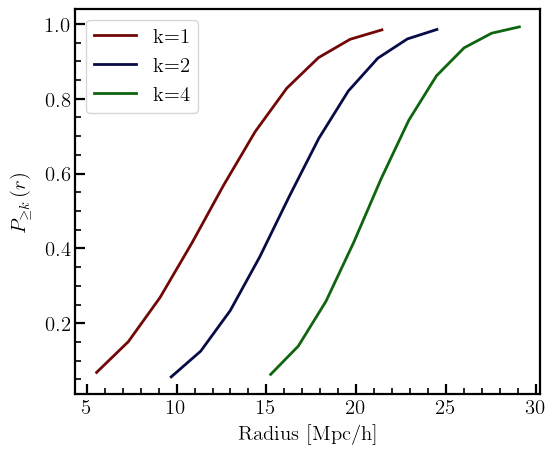

In [13]:
Theory_CDFs = np.zeros((len(k_list), Rbins_pick.shape[1]))

for i, k in enumerate(k_list):
    Theory_CDFs[i] = PoissonUniformCDFs(nbar, Rbins_pick[i], k)

plt.figure(figsize=(6, 5))

for i, k in enumerate(k_list):
    plt.plot(Rbins_pick[i], Theory_CDFs[i], color = c[i], lw=2, label=f'k={k}')

plt.xlabel('Radius [Mpc/h]')
plt.ylabel(r'$P_{\geq k} \,(r)$', labelpad=10)
plt.legend()
plt.show()
plt.close()

**Interpretation:** These curves are the theoretical $k$NN-CDFs for a **Poisson** (i.e. unclustered, purely random) point distribution with the same number density as our halo sample. We use them purely as a diagnostic: `low_bin`/`high_bin` mark the radii where each curve crosses 5% and 95%, i.e. the radial range over which the $k$NN-CDF is neither dominated by empty query balls (CDF too close to 0) nor saturated (CDF too close to 1). Restricting `Rbins_pick` to this range ensures that all the cross-correlation measurements below are computed on well-sampled, low-noise radial bins.


<a name="density-threshold" id="density-threshold"></a>
### 2.5 Density Threshold for the Continuous Field

We also need to set a threshold overdensity (dt) for the continuous field. The probability of the field smoothed at a given radius exceeding this threshold serves as a measure of the intrinsic clustering of the continuous field, similar to the role played by the kNN-CDFs for discrete tracers (see [Banerjee & Abel (2023)](https://academic.oup.com/mnras/article/519/4/4856/6965833) for discussion).

Let's set it to the $75^{\rm th}$ percentile of the overdensity map (dt=75), such that the probability of the field exceeding this value is equal to 0.25 at all distance scales. Feel free to play around with this parameter later (note that currently, `kNNpy` only supports a constant percentile density threshold).


In [14]:
delta_threshold = 75.0

<a name="cdf" id="cdf"></a>
### 2.6 Single-Realisation Cross-Clustering: `TracerFieldCross3D`

Now, we are ready to measure the tracer-field cross-clustering for our mock datasets. Let's use the `TracerFieldCross3D()` method to compute the nearest-neighbour distributions for a single realisation of dark matter halos and the underlying matter field.

The quantities being computed are:
1. the auto-CDFs for the discrete tracers $\mathcal{P}_{\geq k}$,
2. the continuum limit of the auto-CDFs for the continuous field $\mathcal{{P}}_{{>dt}}$, and
3. the tracer-field cross-CDFs $\mathcal{P}_{\geq k, >dt}$.

**Application**: Eishica Chand, Arka Banerjee, Simon Foreman, Francisco Villaescusa-Navarro, [MNRAS](https://doi.org/10.1093/mnras/staf433), Volume 538, Issue 3, April 2025, Pages 2204-221


In [15]:
#Print the API documentation for details on the function usage
help(kNN_3D.TracerFieldCross3D)

Help on function TracerFieldCross3D in module kNNpy.kNN_3D:

TracerFieldCross3D(kList, RBins, BoxSize, QueryPos, TracerPos, Field3D, FieldConstPercThreshold, n_threads=1, ReturnSmoothedFieldDict=False, Verbose=False)
    Returns the probabilities $P_{\geq k}$, $P_{>{\rm dt}}$ and $P_{\geq k,>{\rm dt}}$ for $k$ in `kList`, that quantify the extent of the spatial cross-correlation between the given discrete tracer positions (`TracerPos`) and the given continuous overdensity field (`SmoothedFieldDict`) in three-dimensional space.
    
    1. $P_{\geq k}(r)$: 
        the kNN-CDF of the discrete tracers, evaluated at separation $r$
    
    2. $P_{>{\rm dt}}(r)$: 
        the probability of the overdensity field smoothed with a top-hat filter of radius $r$ exceeding the given constant percentile density threshold
    
    3. $P_{\geq k, >{\rm dt}}(r)$:
        the joint probability of finding at least 'k' tracers within a sphere of radius $r$ AND the overdensity field smoothed at scale $r$

#### Halos Cross $\delta_m$


In [16]:
datahalos_kNN_results = kNN_3D.TracerFieldCross3D(k_list, Rbins_pick, Boxsize, QueryPos, pos_halo_use, del_m, delta_threshold)

data_autoCDFs       = datahalos_kNN_results[0]       #The auto-CDFs
data_pdt            = datahalos_kNN_results[1]       #The intrinsic clustering of the field; is equal to 0.75 at all distance scales for our case 
data_jointCDFs      = datahalos_kNN_results[2]       #The halo-delm cross-CDF


#### Randoms Cross $\delta_m$


In [17]:
Randoms    =  np.random.random((Nhalos,3)).astype(np.float32)*Boxsize
print(f"Position range: {np.min(Randoms,axis=0)} - {np.max(Randoms,axis=0)} Mpc/h")

randoms_kNN_results = kNN_3D.TracerFieldCross3D(k_list, Rbins_pick, Boxsize, QueryPos, Randoms, del_m, delta_threshold)

random_autoCDFs     = randoms_kNN_results[0]    #The auto-CDFs for the randoms
random_pdt          = randoms_kNN_results[1]    #The intrinsic clustering of the field; is equal to 0.75 at all distance scales for our case 
random_jointCDFs    = randoms_kNN_results[2]    #The randoms-field cross-CDF


Position range: [0.02506723 0.00261787 0.00088441] - [999.99845028 999.99028444 999.99856949] Mpc/h


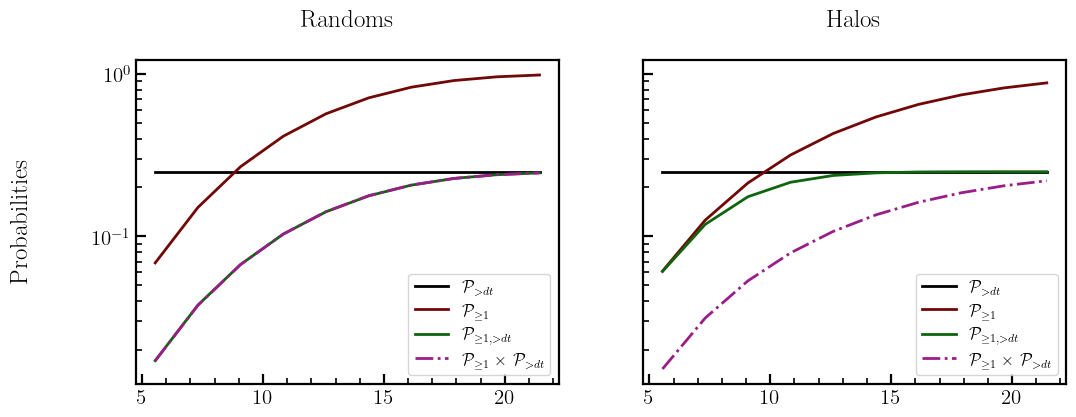

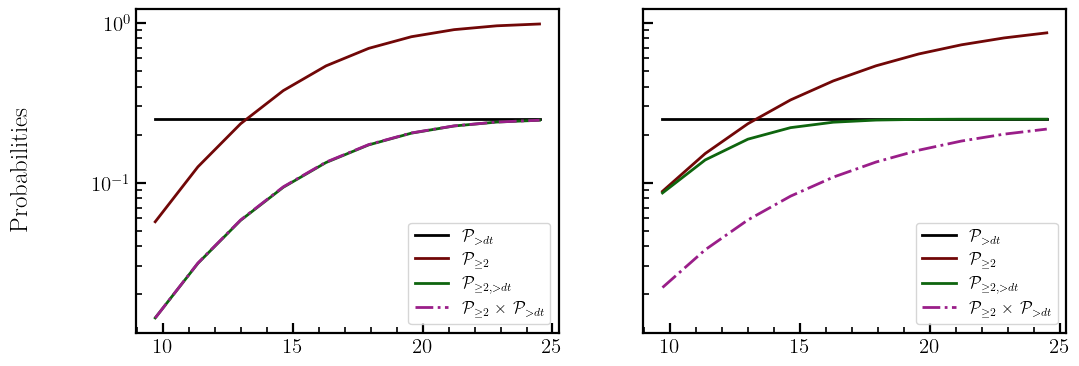

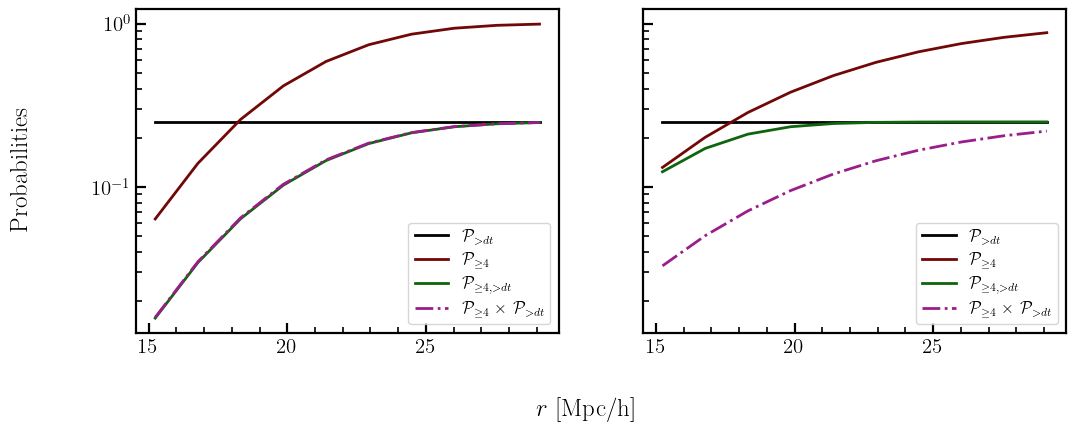

In [18]:
for i, k in enumerate(k_list):

    fig, (ax, ax1) = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True, sharey=True)
    
    ax.plot(Rbins_pick[i], random_pdt[i], c='k', lw=2, label='$\\mathcal{{P}}_{{>dt}}$')
    ax.plot(Rbins_pick[i], random_autoCDFs[i], c=c[0], lw=2, label='$\\mathcal{{P}}_{{\\geq {:.0f}}}$'.format(k))
    ax.plot(Rbins_pick[i], random_jointCDFs[i], c=c[2], lw=2, label='$\\mathcal{{P}}_{{\\geq {:.0f}, >dt}}$'.format(k))
    ax.plot(Rbins_pick[i], random_autoCDFs[i]*random_pdt[i], c=c[4], ls='-.', lw=2, label='$\\mathcal{{P}}_{{\\geq {:.0f}}}$ $\\times$ $\\mathcal{{P}}_{{>dt}}$'.format(k))
    ax.legend(fontsize=12)
    if i==0: ax.set_title('Randoms\n')
    
    ax1.plot(Rbins_pick[i], data_pdt[i], c='k', lw=2, label='$\\mathcal{{P}}_{{>dt}}$')
    ax1.plot(Rbins_pick[i], data_autoCDFs[i], c=c[0], lw=2, label='$\\mathcal{{P}}_{{\\geq {:.0f}}}$'.format(k))
    ax1.plot(Rbins_pick[i], data_jointCDFs[i], c=c[2], lw=2, label='$\\mathcal{{P}}_{{\\geq {:.0f}, >dt}}$'.format(k))
    ax1.plot(Rbins_pick[i], data_autoCDFs[i]*data_pdt[i], c=c[4], ls='-.', lw=2, label='$\\mathcal{{P}}_{{\\geq {:.0f}}}$ $\\times$ $\\mathcal{{P}}_{{>dt}}$'.format(k))
    ax1.legend(fontsize=12)
    if i==0: ax1.set_title('Halos\n')

    if i==len(k_list)-1: fig.supxlabel(r'$r$ [Mpc/h]', y=-0.1)
    fig.supylabel('Probabilities')

    plt.yscale('log')
    plt.show()
    plt.close()

**Interpretation:** Focus on either panel above (the same reading applies at every $k$, just repeated for $k=1,2,4$).

- The **black solid line** ($\mathcal{P}_{>dt}$) takes value of 0.25 for all radii $r$. This is by design, since we chose a constant 75th-percentile density threshold, so the probability of the smoothed field exceeding it is fixed at 0.25 regardless of smoothing scale.
- The **maroon solid line** ($\mathcal{P}_{\geq k}$) is simply the $k$NN auto-CDF of the discrete tracers (halos or randoms) — it rises with $r$ as it becomes increasingly likely to find at least $k$ tracers within a randomly-placed ball of that radius, exactly as in the auto-correlation tutorials.
- The **green solid line** ($\mathcal{P}_{\geq k, >dt}$) is the tracer-field joint CDF: the probability that a randomly-placed ball of radius $r$ both contains at least $k$ tracers *and* has its smoothed field value above the density threshold. It saturates towards $\mathcal{P}_{>dt}=0.75$ at large $r$, since at those scales finding at least $k$ tracers is already close to certain.
- The **magents dash dotted lines** ($\\mathcal{{P}}_{{\\geq {:.0f}}}$ $\\times$ $\\mathcal{{P}}_{{>dt}}$) is simply the product of individual probablities.
- The **value of $\mathcal{P}_{\geq k, >dt}$ on its own doesn't tell us whether the tracers and field are correlated**, since there's a non-zero chance of spatial overlap even if they are completely independent. That's what the **dash-dotted line** ($\mathcal{P}_{\geq k}\times\mathcal{P}_{>dt}$) is for: if the tracers and field were uncorrelated, the joint probability would equal this product. If the tracers preferentially sit in overdense (underdense) regions, the joint probability should be systematically greater (lesser) than this product.

Comparing the two panels: for the **Randoms** (left), the green joint-CDF line sits essentially on top of the dash-dotted product line at all radii — as expected, since by construction the random points carry no information about the matter field. For the **Halos** (right), the joint-CDF line lies clearly *above* the product line, telling us that halos are positively correlated with the matter overdensity field, i.e. they preferentially trace the high-density regions. This holds across all three values of $k$. We'll make this comparison quantitative next with the excess cross-correlation.


#### Excess Cross-Correlation

To make it easier to visualize the clustering signal, we can compute a quantity known as the excess cross-correlation, which is defined as
$$\psi_{k, dt} = \frac{\mathcal{P}_{\geq k, >dt}}{\mathcal{P}_{\geq k}\times\mathcal{{P}}_{{>dt}}}$$

An excess cross-correlation greater (lesser) than 1 implies that the tracers are positively (negatively) correlated with the field, while a unity value indicates that the tracers are uncorrelated with the field.


In [19]:
excess_halos = hf.kNN_excess_cross_corr(data_autoCDFs, data_pdt, data_jointCDFs)
excess_rndm  = hf.kNN_excess_cross_corr(random_autoCDFs, random_pdt, random_jointCDFs)

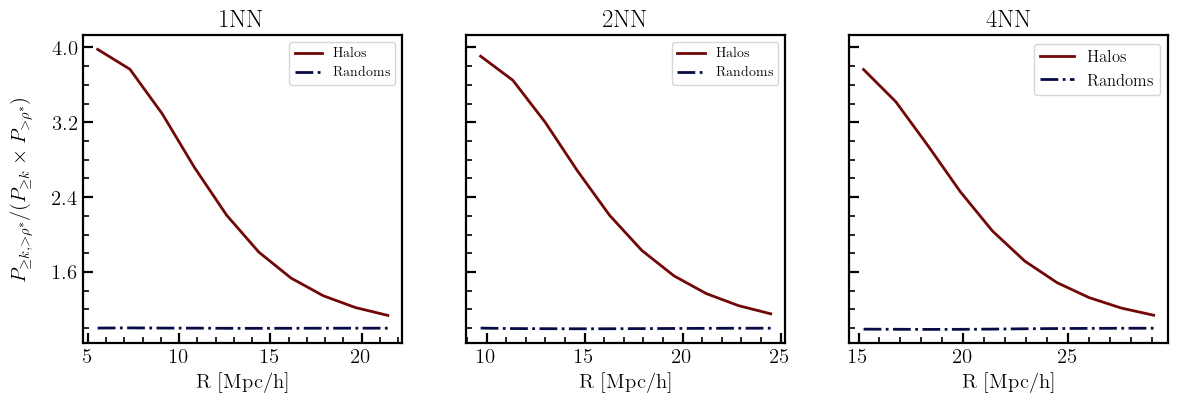

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for i, k in enumerate(k_list):

    ax[i].plot(Rbins_pick[i], excess_halos[i], color =c[0], lw=2, ls='-', label='Halos')
    
    ax[i].plot(Rbins_pick[i], excess_rndm[i], color =c[1], lw=2, ls = '-.', label='Randoms')
    
    ax[i].set_xlabel(r'R [Mpc/h]')
    ax[i].set_title(f'{k}NN')
    ax[i].legend(fontsize = 10)
    ax[i].yaxis.set_major_locator(MaxNLocator(nbins=5))

ax[0].set_ylabel(r'$P_{\geq k, > \rho^*}/ (P_{\geq k} \times P_{>\rho^*})$', labelpad = 15)
plt.legend(fontsize=12)

plt.show()

> **Observation:** The excess cross-correlation $\psi_{k,dt}$ is well above 1 for the halos at all three values of $k$, confirming quantitatively that halos are positively correlated with the matter overdensity field. The randoms, on the other hand, sit essentially flat at $\psi_{k,dt}\approx1$ across all radii, showing no correlation with the field, as expected. Note also that the halo signal is strongest at small $r$ and gradually decays towards 1 at large $r$, since on large enough scales both the tracer and field CDFs saturate towards their asymptotic (uncorrelated-looking) values, washing out the correlation signal.


<a name="datavector" id="datavector"></a>
### 2.7 Multi-Realisation Cross-Clustering: `TracerFieldCross3D_DataVector`

This module returns 'data vectors' of the probabilities $P_{\geq k}$, $P_{>{\rm dt}}$ and $P_{\geq k,>{\rm dt}}$ for $k$ in `kList`, for multiple realisations of the given discrete tracer set (`TracerPosVector`) and a single realisation of the given continuous overdensity field (`Field`). Please refer to the notes to understand why this might be useful.


In [21]:
n_realisations = 5
Nhalos  = 100000
snapnum = 4

pos_halo_use = []

for ireal in range(n_realisations):

    halo_dir = f"{DataPath}/Quijote_simulations/fiducial_LR/{ireal}"
    FoF = readfof.FoF_catalog(halo_dir, snapnum, long_ids=False, swap=False,SFR=False, read_IDs=False)

    pos = (FoF.GroupPos / 1e3).astype(np.float32)
    mass = FoF.GroupMass * 1e10
    idx = np.argsort(mass)[::-1][:Nhalos]
    pos_halo_use.append(pos[idx])

pos_halo_use = np.array(pos_halo_use)
print(f"Shape pos_halo_use: {pos_halo_use.shape}")

Shape pos_halo_use: (5, 100000, 3)


We will correlate with $\delta_m$ of realisation 0, so the cross-correlation should be higher for realisation 0.


In [22]:
#Print the API documentation for details on the function usage
help(kNN_3D.TracerFieldCross3D_DataVector)

Help on function TracerFieldCross3D_DataVector in module kNNpy.kNN_3D:

TracerFieldCross3D_DataVector(kList, RBins, BoxSize, QueryPos, TracerPosVector, Field, FieldConstPercThreshold, n_threads=1, ReturnSmoothedDict=False, Verbose=False)
    Returns 'data vectors' of the  the probabilities $P_{\geq k}$, $P_{>{\rm dt}}$ and $P_{\geq k,>{\rm dt}}$ [refer to kNNpy.kNN_3D.TracerFieldCross for definitions] for $k$ in `kList` for multiple realisations of the given discrete tracer set [`TracerPosVector`] and a single realisation of the given continuous overdensity field (`Field`). Please refer to notes to understand why this might be useful.
        
    Parameters
    ----------
    kList : list of int
        List of nearest neighbours to compute. For example, if ``kList = [1, 2, 4]``, the first, second and fourth-nearest neighbour distributions will be computed.
    
    RBins : list of numpy float arrays
        List of radial distance arrays (in comoving Mpc/$h$), one for each value in `

In [23]:
datahalos_Nrealiz_kNN_results = TracerFieldCross3D_DataVector(k_list, Rbins_pick, Boxsize, QueryPos, pos_halo_use, del_m, delta_threshold)

data_autoCDFs_Nr = datahalos_Nrealiz_kNN_results[0]      
data_pdt_Nr      = datahalos_Nrealiz_kNN_results[1]       
data_jointCDFs_Nr = datahalos_Nrealiz_kNN_results[2]



In [24]:
data_autoCDFs_Nr = np.array(data_autoCDFs_Nr)
data_pdt_Nr      = np.array(data_pdt_Nr)
data_jointCDFs_Nr = np.array(data_jointCDFs_Nr)
print(f"Shape of data_autoCDFs_Nr: {data_autoCDFs_Nr.shape}")

Shape of data_autoCDFs_Nr: (3, 5, 10)


#### Plots


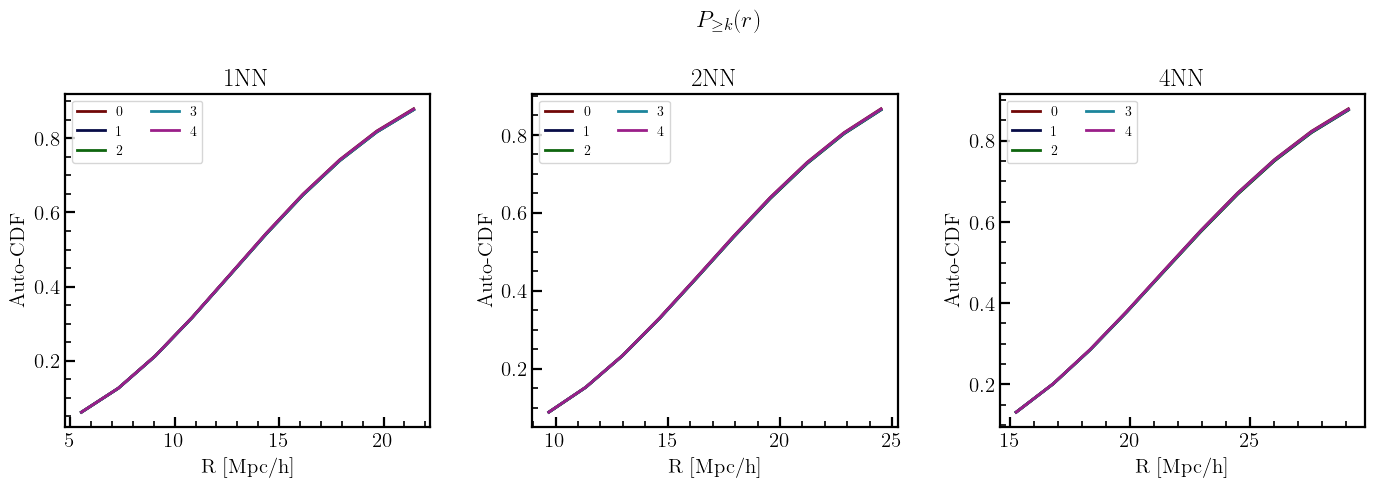

In [25]:
# Plotting the results - Halos

fig, ax = plt.subplots(1, 3, figsize=(14, 5))
axs = ax.flatten()

for i, k in enumerate(k_list):
    for j in range(n_realisations):
        ax[i].plot(Rbins_pick[i], data_autoCDFs_Nr[i,j], ls = '-', lw=2, color=c[j], label =f"{j}")

# for i in range(len(axs)):
    axs[i].set_xlabel(r'R [Mpc/h]')
    axs[i].set_ylabel(f'Auto-CDF')
    axs[i].legend(fontsize = 10, ncol=2)
    axs[i].set_title(f'{k}NN')
    axs[i].yaxis.set_major_locator(MaxNLocator(nbins=5))

fig.suptitle(r'$P_{\geq k}(r)$', x=0.53, fontsize=17)
plt.tight_layout(w_pad = 2, h_pad = 2)
plt.show()
# plt.close

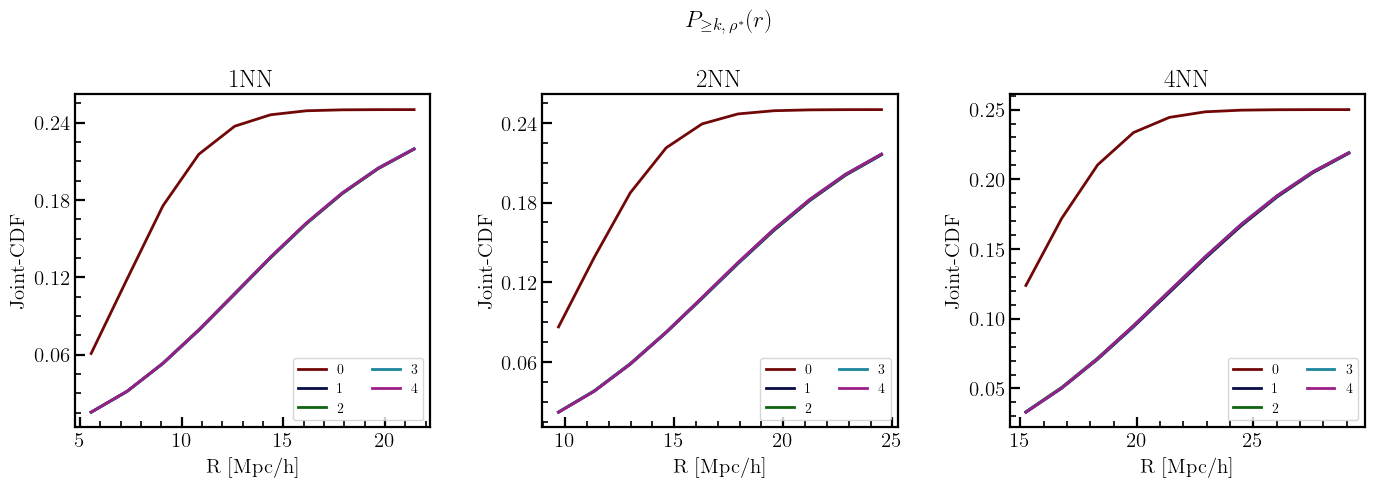

In [26]:
# Plotting the results - Halos

fig, ax = plt.subplots(1, 3, figsize=(14, 5))
axs = ax.flatten()

for i, k in enumerate(k_list):
    for j in range(n_realisations):
        ax[i].plot(Rbins_pick[i], data_jointCDFs_Nr[i,j], ls = '-', lw=2,color=c[j], label =f"{j}")

# for i in range(len(axs)):
    axs[i].set_xlabel(r'R [Mpc/h]')
    axs[i].set_ylabel(f'Joint-CDF')
    axs[i].legend(fontsize = 10, ncol=2)
    axs[i].set_title(f'{k}NN')
    axs[i].yaxis.set_major_locator(MaxNLocator(nbins=5))


fig.suptitle(r'$P_{\geq k,\, \rho^*}(r)$', x=0.53,fontsize=17)
plt.tight_layout(w_pad = 2, h_pad = 2)
plt.show()
# plt.close

**Interpretation:** Each panel now overlays the joint-CDF (this plot) for 5 independent halo realisations (0-4), all cross-correlated against the **same** matter field (realisation 0). Since realisation 0's halos are drawn from the same simulation as the matter field used here, we expect realisation 0 to show the strongest cross-correlation signal, while the other realisations — being statistically independent of this particular field — should show a weaker, more random-like signal. This is examined directly in the excess-CDF below.


#### Compute Excess-CDF


In [27]:
excess_TrF_Nr = hf.kNN_excess_cross_corr(data_autoCDFs_Nr, data_pdt_Nr, data_jointCDFs_Nr)

In [28]:
print('Excess-CDF shape:', np.shape(excess_TrF_Nr)); excess_TrF_Nr = np.array(excess_TrF_Nr); print(excess_TrF_Nr.shape)

Excess-CDF shape: (3, 5, 10)
(3, 5, 10)


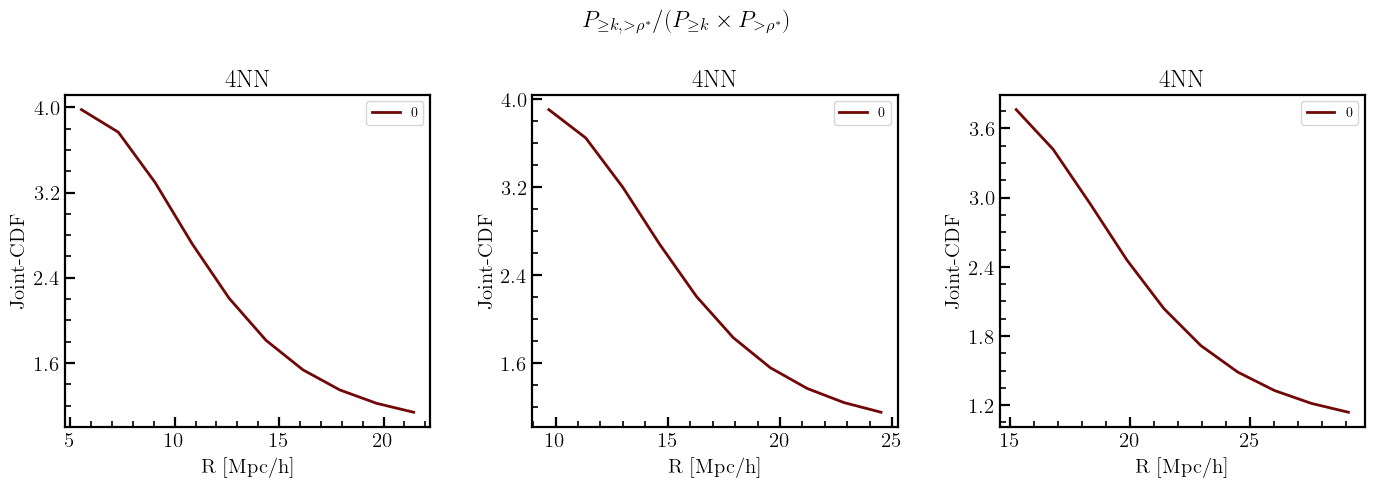

In [31]:
# Plotting the results - Halos

fig, ax = plt.subplots(1, 3, figsize=(14, 5))
axs = ax.flatten()

for i, k in enumerate(k_list):
    ax[i].plot(Rbins_pick[i], excess_TrF_Nr[i,0], ls = '-', lw=2,color=c[0], label =f"{0}")

for i in range(len(axs)):
    axs[i].set_xlabel(r'R [Mpc/h]')
    axs[i].set_ylabel(f'Joint-CDF')
    axs[i].legend(fontsize = 10, ncol=2)
    axs[i].set_title(f'{k}NN')
    axs[i].yaxis.set_major_locator(MaxNLocator(nbins=5))
    # axs[i].set_ylim(0.97, 1.03)
fig.suptitle(r'$P_{\geq k, > \rho^*}/ (P_{\geq k} \times P_{>\rho^*})$', fontsize=17)
plt.tight_layout(w_pad = 2, h_pad = 2)
plt.show()
# plt.close

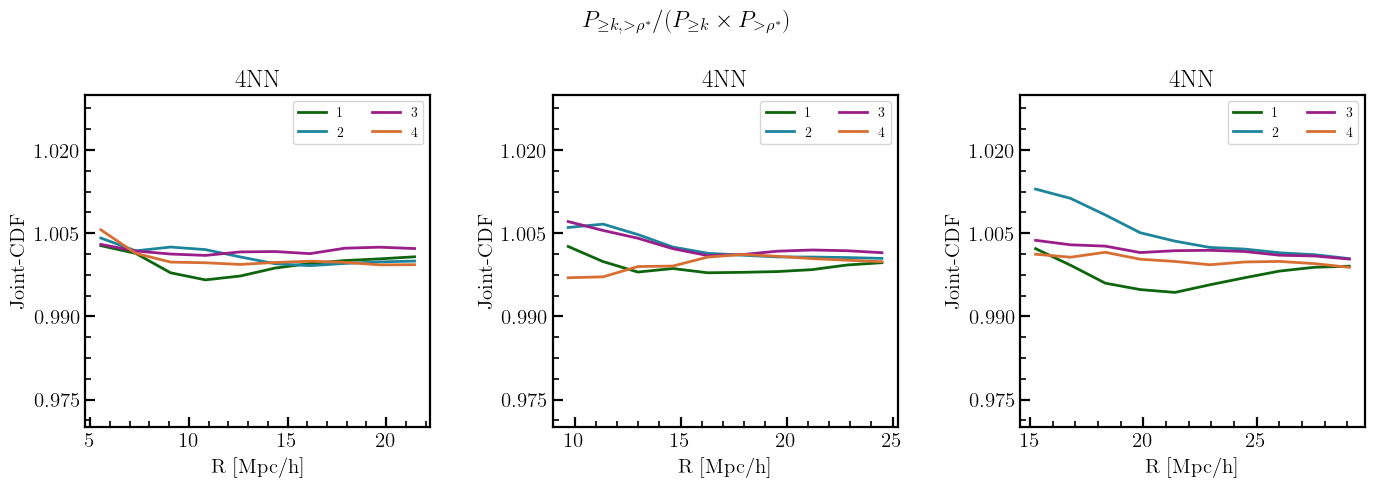

In [32]:
# Plotting the results - Halos

fig, ax = plt.subplots(1, 3, figsize=(14, 5))
axs = ax.flatten()

for i, k in enumerate(k_list):
    for j in range(1,n_realisations):
        ax[i].plot(Rbins_pick[i], excess_TrF_Nr[i,j], ls = '-', lw=2,color=c[j+1], label =f"{j}")

for i in range(len(axs)):
    axs[i].set_xlabel(r'R [Mpc/h]')
    axs[i].set_ylabel(f'Joint-CDF')
    axs[i].legend(fontsize = 10, ncol=2)
    axs[i].set_title(f'{k}NN')
    axs[i].yaxis.set_major_locator(MaxNLocator(nbins=5))
    axs[i].set_ylim(0.97, 1.03)
fig.suptitle(r'$P_{\geq k, > \rho^*}/ (P_{\geq k} \times P_{>\rho^*})$', fontsize=17)
plt.tight_layout(w_pad = 2, h_pad = 2)
plt.show()
# plt.close

**Interpretation:** As anticipated, the excess cross-correlation for realisation 0 is systematically larger than unity, while the other realisations (1-4), which are cross-correlated against a matter field they were not drawn from, hover much closer to $\psi_{k,dt}=1$ — consistent with little to no real correlation. This confirms that `TracerFieldCross3D_DataVector` correctly recovers a genuine signal only when the tracer and field realisations are physically associated, and demonstrates how the multi-realisation data vector can be used to assess the significance of a cross-correlation detection against the realisation-to-realisation scatter.
